In [ ]:
# knn on breast cancer dataset 

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("knn_breast_cancer_dataset.csv")

In [4]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.shape

(569, 33)

In [8]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [10]:
df.drop(columns=['id'], inplace=True)

In [11]:
df.drop(columns=['Unnamed: 32'], inplace=True)

In [12]:
# changing the model target value from M,B to 1,0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [13]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [14]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
# training knn model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
y_pred = knn.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9473684210526315

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[68  3]
 [ 3 40]]


In [21]:
# F1 SCORE - Balances precision and recall.USED FOR IMBALANCED DATASET
from sklearn.metrics import f1_score

f1_score(y_test,y_pred)


0.9302325581395349

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for k in range(1,31):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    pred = knn.predict(X_test)

    scores.append(
        accuracy_score(y_test,pred)
    )

for k,score in enumerate(scores, start=1):
    print(k,score)

1 0.9385964912280702
2 0.9473684210526315
3 0.9473684210526315
4 0.956140350877193
5 0.9473684210526315
6 0.956140350877193
7 0.9473684210526315
8 0.956140350877193
9 0.9649122807017544
10 0.956140350877193
11 0.956140350877193
12 0.956140350877193
13 0.956140350877193
14 0.956140350877193
15 0.956140350877193
16 0.9473684210526315
17 0.9473684210526315
18 0.9473684210526315
19 0.9473684210526315
20 0.9473684210526315
21 0.9473684210526315
22 0.9473684210526315
23 0.9473684210526315
24 0.9473684210526315
25 0.9473684210526315
26 0.9473684210526315
27 0.9473684210526315
28 0.956140350877193
29 0.956140350877193
30 0.956140350877193


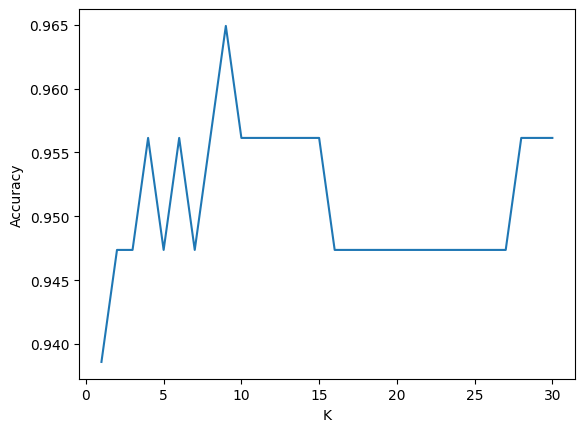

In [23]:
import matplotlib.pyplot as plt

plt.plot(range(1,31),scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [24]:
# from graph using k = 9 as it consist of highest accuracy,also now checking 
# it to detect . What happened to False Negatives?
from sklearn.metrics import confusion_matrix

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print(confusion_matrix(y_test,y_pred))

[[69  2]
 [ 2 41]]


In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

for k in range(1,31):

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5
    )

    print(
        f"K={k}, Mean CV Accuracy={scores.mean():.4f}"
    )

K=1, Mean CV Accuracy=0.9407
K=2, Mean CV Accuracy=0.9473
K=3, Mean CV Accuracy=0.9604
K=4, Mean CV Accuracy=0.9582
K=5, Mean CV Accuracy=0.9604
K=6, Mean CV Accuracy=0.9560
K=7, Mean CV Accuracy=0.9604
K=8, Mean CV Accuracy=0.9538
K=9, Mean CV Accuracy=0.9538
K=10, Mean CV Accuracy=0.9538
K=11, Mean CV Accuracy=0.9516
K=12, Mean CV Accuracy=0.9538
K=13, Mean CV Accuracy=0.9582
K=14, Mean CV Accuracy=0.9538
K=15, Mean CV Accuracy=0.9538
K=16, Mean CV Accuracy=0.9538
K=17, Mean CV Accuracy=0.9560
K=18, Mean CV Accuracy=0.9538
K=19, Mean CV Accuracy=0.9538
K=20, Mean CV Accuracy=0.9538
K=21, Mean CV Accuracy=0.9560
K=22, Mean CV Accuracy=0.9560
K=23, Mean CV Accuracy=0.9560
K=24, Mean CV Accuracy=0.9538
K=25, Mean CV Accuracy=0.9538
K=26, Mean CV Accuracy=0.9516
K=27, Mean CV Accuracy=0.9516
K=28, Mean CV Accuracy=0.9516
K=29, Mean CV Accuracy=0.9538
K=30, Mean CV Accuracy=0.9495


In [26]:
# from above interpretation
# A single test split is only one sample of reality.
# Cross-validation uses multiple train-validation splits and is usually more trustworthy.

# K=3 -> 96.04%
# K=5 -> 96.04%
# K=7 -> 96.04%

# Notice something?

# The performance plateau starts around:
# K = 3
# and remains almost identical for many values.